p.69~87

In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [5]:
cols = ['price', 'maint', 'doors', 'persons', 'lug_capacity', 'safety', 'output']
dataset = pd.read_csv('/content/drive/MyDrive/data/car.data', names=cols)
display(dataset.head())

,price,maint,doors,persons,lug_capacity,safety,output
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


<Axes: ylabel='count'>

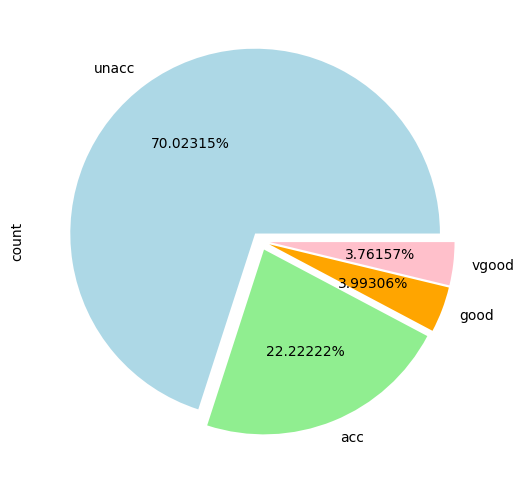

In [6]:
fig_size = plt.rcParams["figure.figsize"]
fig_size[0] = 8
fig_size[1] =6
plt.rcParams["figure.figsize"] = fig_size
dataset.output.value_counts().plot(kind='pie', autopct='%0.05f%%',
                                   colors=['lightblue','lightgreen','orange','pink'], explode=(0.05, 0.05 , 0.05 , 0.05))

결과에 따르면 대부분의 자동차는 허용 불가능한 상태에 있고, 20%만 허용 가능한 수준이다. 즉, 양호한 상태의 자동차 비율이 매우 낮은 것을 볼 수 있다.

딥러닝은 통계 알고리즘을 기반으로 하기 때문에 단어를 숫자(텐서)로 변환해야 한다.

- astype()메서드를 이용하여 범주 특성을 갖는 데이터를 범주형 타입으로 변환한다.

In [9]:
categorical_columns = ['price', 'maint', 'doors', 'persons', 'lug_capacity', 'safety']

for category in categorical_columns:
  dataset[category] = dataset[category].astype('category')

price = dataset['price'].cat.codes.values
maint = dataset['maint'].cat.codes.values
doors = dataset['doors'].cat.codes.values
persons = dataset['persons'].cat.codes.values
lug_capacity = dataset['lug_capacity'].cat.codes.values
safety = dataset['safety'].cat.codes.values

categorical_data = np.stack([price, maint, doors, persons, lug_capacity, safety],1)
categorical_data[:10]

array([[3, 3, 0, 0, 2, 1],
       [3, 3, 0, 0, 2, 2],
       [3, 3, 0, 0, 2, 0],
       [3, 3, 0, 0, 1, 1],
       [3, 3, 0, 0, 1, 2],
       [3, 3, 0, 0, 1, 0],
       [3, 3, 0, 0, 0, 1],
       [3, 3, 0, 0, 0, 2],
       [3, 3, 0, 0, 0, 0],
       [3, 3, 0, 1, 2, 1]], dtype=int8)

**np.staack과 np.concatenate**
넘파이 객체를 합칠 때 사용하는 메서드로는 이 두가지가 있다. 이 두가지 메서드는 차원의 유지 여부에 대한 차이가 있다. np.concatenate는 다음 그림과 같이 선택한 축을 기준으로 두 개의 배열을 연결한다.

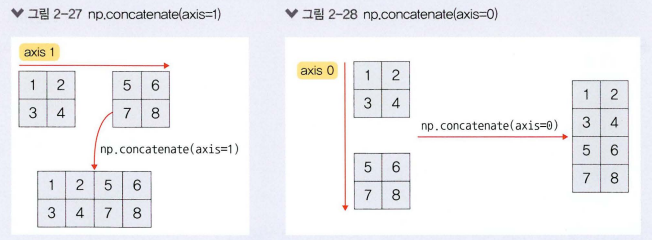

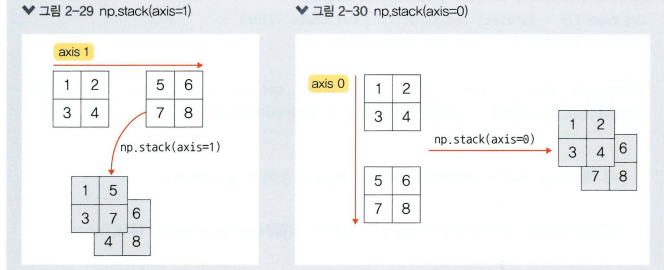

In [10]:
categorical_data = torch.tensor(categorical_data, dtype=torch.int64)
categorical_data[:10]

tensor([[3, 3, 0, 0, 2, 1],
        [3, 3, 0, 0, 2, 2],
        [3, 3, 0, 0, 2, 0],
        [3, 3, 0, 0, 1, 1],
        [3, 3, 0, 0, 1, 2],
        [3, 3, 0, 0, 1, 0],
        [3, 3, 0, 0, 0, 1],
        [3, 3, 0, 0, 0, 2],
        [3, 3, 0, 0, 0, 0],
        [3, 3, 0, 1, 2, 1]])

In [11]:
outputs = pd.get_dummies(dataset.output)
outputs = outputs.values
outputs = torch.tensor(outputs).flatten()

print(categorical_data.shape)
print(outputs.shape)

torch.Size([1728, 6])
torch.Size([6912])


워드 임베딩: 유사한 단어끼리 유사하게 인코딩되도록 표현하는 방법

높은 차원의 임베딩일수록 단어 간의 세부적인 관계를 잘 파악할 수 있다. 따라서 단일 숫자로 변환된 넘파이 배열을 N차원으로 변경하여 사용한다.

In [14]:
categorical_column_sizes = [len(dataset[column].cat.categories) for column in categorical_columns]
categorical_embedding_sizes = [(col_size, min(50, (col_size + 1) // 2)) for col_size in categorical_column_sizes]
print(categorical_embedding_sizes)

[(4, 2), (4, 2), (4, 2), (3, 2), (3, 2), (3, 2)]


In [17]:
total_records = 1728
test_records = int(total_records * .2)

categorical_train_data = categorical_data[:total_records-test_records]
categorical_test_data = categorical_data[total_records-test_records:total_records]
train_outputs = outputs[:total_records - test_records]
test_outputs = outputs[total_records - test_records:total_records]

In [18]:
print(len(categorical_train_data))
print(len(train_outputs))
print(len(categorical_test_data))
print(len(test_outputs))

1383
1383
345
345


In [21]:
class Model(nn.Module):
  def __init__(self, embedding_size, output_size, layers, p=0.4):
    super().__init__()
    self.all_embeddings = nn.ModuleList([nn.Embedding(ni, nf) for ni, nf in embedding_size])
    self.embedding_dropout = nn.Dropout(p)

    all_layers = []
    num_categorical_cols = sum((nf for ni, nf in embedding_size))
    input_size = num_categorical_cols

    for i in layers:
      all_layers.append(nn.Linear(input_size, i))
      all_layers.append(nn.ReLU(inplace=True))
      all_layers.append(nn.BatchNorm1d(i))
      all_layers.append(nn.Dropout(p))
      input_size = i

    all_layers.append(nn.Linear(layers[-1], output_size))
    self.layers = nn.Sequential(*all_layers)

  def forward(self, x_categorical):
    embeddings = []
    for i, e in enumerate(self.all_embeddings):
      embeddings.append(e(x_categorical[:, i]))
    x = torch.cat(embeddings, 1)
    x = self.embedding_dropout(x)
    x = self.layers(x)
    return x

In [22]:
model = Model(categorical_embedding_sizes, 4, [200, 100, 50], p=0.4)
print(model)

Model(
  (all_embeddings): ModuleList(
    (0-2): 3 x Embedding(4, 2)
    (3-5): 3 x Embedding(3, 2)
  )
  (embedding_dropout): Dropout(p=0.4, inplace=False)
  (layers): Sequential(
    (0): Linear(in_features=12, out_features=200, bias=True)
    (1): ReLU(inplace=True)
    (2): BatchNorm1d(200, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=200, out_features=100, bias=True)
    (5): ReLU(inplace=True)
    (6): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.4, inplace=False)
    (8): Linear(in_features=100, out_features=50, bias=True)
    (9): ReLU(inplace=True)
    (10): BatchNorm1d(50, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): Dropout(p=0.4, inplace=False)
    (12): Linear(in_features=50, out_features=4, bias=True)
  )
)


In [23]:
loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [24]:
if torch.cuda.is_available():
  device = torch.device('cuda')
else:
  device = torch.device('cpu')

In [26]:
epochs = 500
aggregated_losses = []
train_outputs = train_outputs.to(device=device, dtype=torch.int64)

for i in range(epochs):
    i += 1
    y_pred = model(categorical_train_data).to(device)
    single_loss = loss_function(y_pred, train_outputs)
    aggregated_losses.append(single_loss)

    if i % 25 == 1:
        print(f'epoch: {i:3} loss: {single_loss.item():10.8f}')

    optimizer.zero_grad()
    single_loss.backward()
    optimizer.step()

print(f'epoch: {i:3} loss: {single_loss.item():10.10f}')

epoch:   1 loss: 1.59545016
epoch:  26 loss: 1.41099012
epoch:  51 loss: 1.30870676
epoch:  76 loss: 1.20414615
epoch: 101 loss: 1.06619430
epoch: 126 loss: 0.94754481
epoch: 151 loss: 0.83750206
epoch: 176 loss: 0.74920374
epoch: 201 loss: 0.68523192
epoch: 226 loss: 0.65951097
epoch: 251 loss: 0.65393227
epoch: 276 loss: 0.61773306
epoch: 301 loss: 0.62024289
epoch: 326 loss: 0.60010195
epoch: 351 loss: 0.60221392
epoch: 376 loss: 0.58525717
epoch: 401 loss: 0.58873910
epoch: 426 loss: 0.57746458
epoch: 451 loss: 0.58014804
epoch: 476 loss: 0.57604909
epoch: 500 loss: 0.5757596493


In [34]:
test_outputs = test_outputs.to(device=device, dtype=torch.int64)
with torch.no_grad():
  y_val = model(categorical_test_data)
  loss = loss_function(y_eval, test_outputs)

print(f'Loss:{loss:.8f}')

Loss:0.55991757


In [35]:
print(y_val[:5])

tensor([[ 2.4340,  1.2824, -2.8857, -2.8451],
        [ 6.1019,  4.1542, -7.3972, -7.1954],
        [ 2.7396,  1.5707, -3.9761, -3.7783],
        [ 1.6813,  0.8408, -2.1151, -1.8851],
        [ 3.4999,  2.0889, -4.3936, -4.4453]])


In [36]:
y_val = np.argmax(y_val, axis=1)
print(y_val[:5])

tensor([0, 0, 0, 0, 0])


In [38]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print(confusion_matrix(test_outputs, y_val))
print(classification_report(test_outputs, y_val))
print(accuracy_score(test_outputs, y_val))

[[258   1]
 [ 86   0]]
              precision    recall  f1-score   support

           0       0.75      1.00      0.86       259
           1       0.00      0.00      0.00        86

    accuracy                           0.75       345
   macro avg       0.38      0.50      0.43       345
weighted avg       0.56      0.75      0.64       345

0.7478260869565218


- TP: 모델이 1이라고 예측, 실제값도 1인 경우
- TN: 모델이 0이라고 예측, 실제값도 0인 경우
- FP: 모델이 1이라고 예측, 실제값은 0인 경우
- FN: 모델이 0이라고 예측, 실제값은 1인 경우

- $정확도 = 전체 예측 건 수에서 정답을 맞힌 건수의 비율$
- $재현율 = 실제로 정답이 1이라고 할 때 모델도 1로 예측한 비율$
- $정밀도 = 모델이 1이라고 예측한 것 중 실제로 정답이 1인 비율$

- F1-Score: 일반적으로 정밀도와 재현율은 **트레이드 오프**관계이다.

이러한 트레이드오프 문제를 해결하려고 정밀도와 재현율의 조화 평균을 이용한 이 Fl-스코어 평가이다.